# Prepare the features

- [X] BOP features arrangement and averagings
- [O] Library Features arrangement ad averaging
  average per polihedra.
  average per structure.
  atoms in each polyhedra.
- [X] Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

# Included averages

- moments of the total density of states :  

$$ m_0^i = \left( \sum_{j} m_j^i \right)/N_{atoms} $$

- CP averaged moments, norm to total number of atoms:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{atoms}
$$ 

- CP averaged moments, norm atoms in CP:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{CP}
$$ 

# but I should also include:

- correlation matrices for pair of sets

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Cr-Co-W'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

In [2]:
BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))

# Load Features 

In [3]:
AtomicFeaturesFile = os.path.join(descriptorlocation, 'matminer_atomic_features.pkl')
CompositionFeaturesFile = os.path.join(descriptorlocation, 'matminer_composition_features.pkl')

Coordination Number averages

In [4]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'CNAVPyscal.pkl')

In [5]:
bopmodels = ['canonical', 'projections', 'projections_os']
bopfeaturesfile = {model: os.path.join(descriptorlocation, f'curated_{system}_initial_{model}_table_WUBIND_16.pkl') for model in bopmodels}

In [6]:
PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)
BopFeatures = {model: pd.read_pickle(modelfile) for model, modelfile in bopfeaturesfile.items()}
AtomicFeatures = pd.read_pickle(AtomicFeaturesFile)
CompositionFeatures = pd.read_pickle(CompositionFeaturesFile)

# Outlier detection 

I know there are outliers. It is enaugh with looking at the following plots:

In [7]:
BopFeatures['canonical']

,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,moments_1_CN13,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Co_pv6W_sv6.C14-BBA.FM,-42.133341,-12.456832,-10.739578,0.000000,0.000000,0.000000,-1.717254,2.496405,2.061708,0.000000,...,0.000000,0.000000,0.000000,0.676294,1.106267,1.192875,0.000000,0.000000,0.000000,0.904122
Co_pv6W_sv6.C14-BBA.NM,-42.133341,-12.456832,-10.739578,0.000000,0.000000,0.000000,-1.717254,2.496405,2.061708,0.000000,...,0.000000,0.000000,0.000000,0.676294,1.106267,1.192875,0.000000,0.000000,0.000000,0.904122
Cr_pv6W_sv2.D0_19-A3B.FM,-42.039279,-9.848541,-9.848541,0.000000,0.000000,0.000000,0.000000,1.530625,1.530625,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.137590,1.137590,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,-42.039279,-9.848541,-9.848541,0.000000,0.000000,0.000000,0.000000,1.530625,1.530625,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.137590,1.137590,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,-143.858275,-11.663917,-1.922840,0.000000,-8.983963,-0.757114,0.000000,1.797828,0.572043,0.000000,...,0.000000,0.811870,0.206203,0.000000,1.224174,1.238260,0.000000,1.215240,1.227311,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,-73.831298,-10.919301,-3.325984,0.000000,-6.088028,-0.645266,-0.860024,1.828545,1.308482,0.000000,...,0.000000,0.263546,0.268330,0.267437,1.093711,1.221539,0.000000,0.974006,0.817860,0.996110
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,-156.777732,-11.359083,-1.948216,0.000000,-8.689776,-0.721091,0.000000,1.713707,0.590231,0.000000,...,0.000000,0.795918,0.199930,0.000000,1.224170,1.188754,0.000000,1.255536,1.191643,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,-156.777732,-11.359083,-1.948216,0.000000,-8.689776,-0.721091,0.000000,1.713707,0.590231,0.000000,...,0.000000,0.795918,0.199930,0.000000,1.224170,1.188754,0.000000,1.255536,1.191643,0.000000
Co_pv13W_sv16.chi-ABAB.NM,-127.642589,-12.724241,-9.243040,-2.484693,0.000000,0.000000,-0.996509,2.241933,1.137087,0.838303,...,0.626761,0.000000,0.000000,0.258547,1.251701,1.437266,1.179081,0.000000,0.000000,1.006199


<AxesSubplot:xlabel='U_bond_atom_list_1_0', ylabel='Count'>

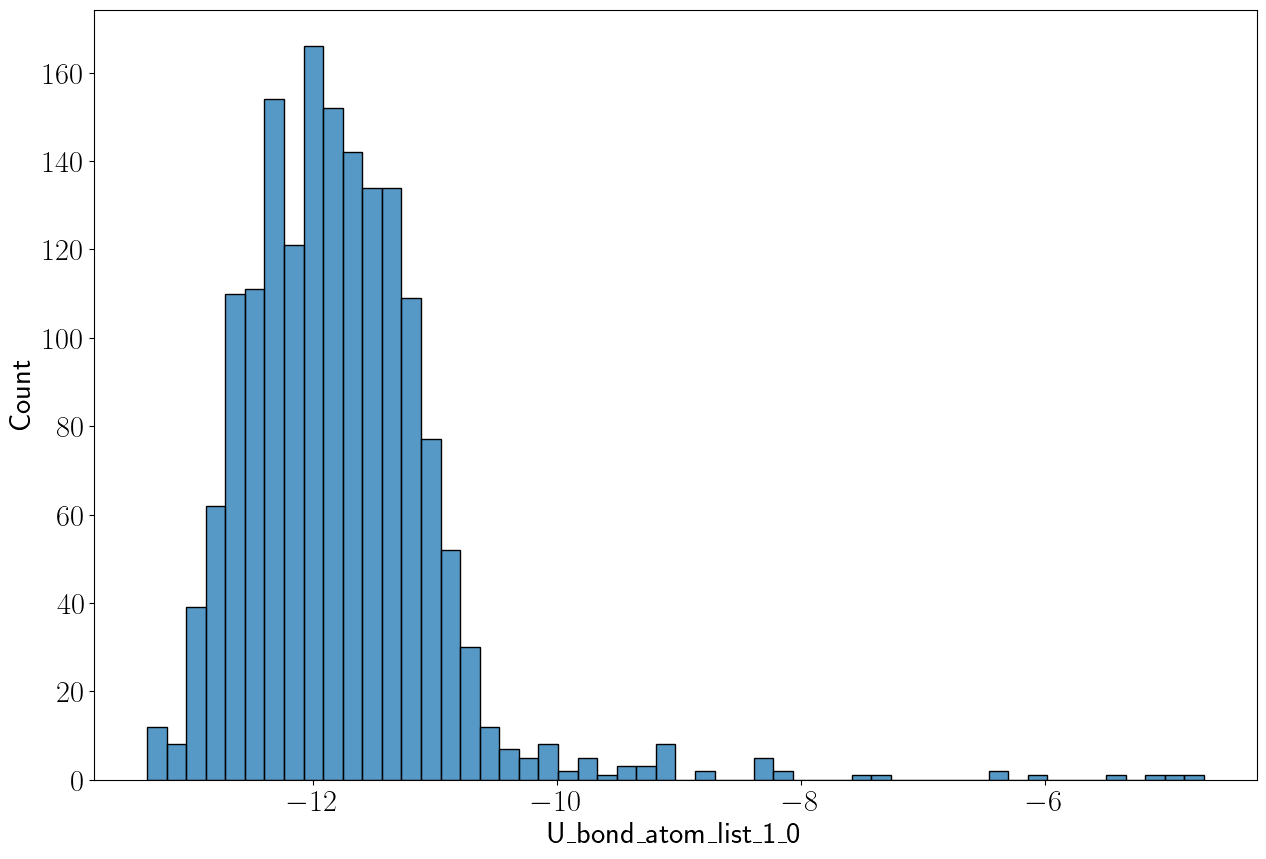

In [8]:
sns.histplot(BopFeatures['canonical']['U_bond_atom_list_1_0'])

# compiling FULL features 

In [12]:
AllFeatures = [AtomicFeatures,CompositionFeatures, BopFeatures['canonical'] ] # 

In [13]:
FullSetOfFeatures = pd.concat(AllFeatures, axis = 1)

# categorical features transformation

In [14]:
from sklearn import set_config
from sklearn.compose import make_column_selector
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

In [15]:
cat_selector = make_column_selector(dtype_include=object)
categorical_features_names = cat_selector(FullSetOfFeatures)
CategoricalFeatures = FullSetOfFeatures[categorical_features_names]

In [16]:
oencoder = OrdinalEncoder()
oencoder.fit(X=CategoricalFeatures)
replace_categorical_features_values  = oencoder.transform(CategoricalFeatures)

In [17]:
FullSetOfFeatures[categorical_features_names] = replace_categorical_features_values

In [18]:
FullSetOfFeatures[categorical_features_names]

,HOMO_character,HOMO_element,LUMO_character,LUMO_element
Cr_pv10Co_pv14.C36-BABBA.FM,0.0,0.0,0.0,0.0
Co_pv14W_sv16.sigma-AABBA.FM,0.0,2.0,0.0,2.0
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,0.0,2.0,0.0,2.0
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,1.0,0.0,1.0,0.0
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,1.0,0.0,1.0,0.0
...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,0.0,0.0,0.0,0.0
Cr_pv2W_sv11.mu-BBABB.FM,0.0,2.0,0.0,2.0
Cr_pv20Co_pv4.C36-BAAAA.FM,1.0,0.0,1.0,1.0
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,0.0,2.0,0.0,2.0


# Fix Column Names  

In [19]:
def fix_column_name(thecolumn):
    return thecolumn.replace(' ','_')

In [20]:
columns = FullSetOfFeatures.columns

In [21]:
newcolumns = {col: fix_column_name(col) for col in columns}

In [22]:
FullSetOfFeatures.rename(columns=newcolumns, inplace=True)

In [23]:
FullSetOfFeatures

,MagpieData_minimum_Number,MagpieData_maximum_Number,MagpieData_range_Number,MagpieData_mean_Number,MagpieData_avg_dev_Number,MagpieData_mode_Number,MagpieData_minimum_MendeleevNumber,MagpieData_maximum_MendeleevNumber,MagpieData_range_MendeleevNumber,MagpieData_mean_MendeleevNumber,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Cr_pv10Co_pv14.C36-BABBA.FM,24.0,27.0,3.0,26.800000,0.373333,27.0,49.0,58.0,9.0,57.400000,...,0.000000,0.000000,0.000000,0.644704,1.081734,1.156284,0.000000,0.000000,0.000000,0.901329
Co_pv14W_sv16.sigma-AABBA.FM,27.0,74.0,47.0,70.218391,6.954684,74.0,51.0,58.0,7.0,51.563218,...,0.000000,0.903237,0.224615,0.000000,1.224173,1.311936,0.000000,1.187306,1.155464,0.000000
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,24.0,74.0,50.0,38.250000,17.875000,27.0,49.0,58.0,9.0,54.750000,...,0.000000,0.000000,0.000000,0.675372,1.081730,1.156280,0.000000,0.000000,0.000000,0.901326
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,24.0,74.0,50.0,37.750000,18.125000,27.0,49.0,58.0,9.0,53.250000,...,0.000000,0.000000,0.000000,0.665089,1.081731,1.096157,0.000000,0.000000,0.000000,1.050804
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,24.0,74.0,50.0,37.750000,18.125000,27.0,49.0,58.0,9.0,53.250000,...,0.000000,0.000000,0.000000,0.680012,1.081731,1.103530,0.000000,0.000000,0.000000,1.035868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,24.0,27.0,3.0,26.774566,0.416987,27.0,49.0,58.0,9.0,57.323699,...,0.576278,0.000000,0.000000,0.237722,1.251703,1.437268,1.179083,0.000000,0.000000,1.006202
Cr_pv2W_sv11.mu-BBABB.FM,24.0,74.0,50.0,73.107143,1.753827,74.0,49.0,51.0,2.0,50.964286,...,0.000000,0.294869,0.300221,0.299222,1.093709,1.221533,0.000000,0.974009,0.817863,0.996110
Cr_pv20Co_pv4.C36-BAAAA.FM,24.0,27.0,3.0,26.000000,1.333333,27.0,49.0,58.0,9.0,55.000000,...,0.000000,0.000000,0.000000,0.598308,1.081733,1.156285,0.000000,0.000000,0.000000,0.901326
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,24.0,74.0,50.0,46.083333,23.263889,27.0,49.0,58.0,9.0,53.583333,...,0.000000,0.000000,0.000000,0.686115,1.081730,1.096154,0.000000,0.000000,0.000000,1.050805


# Unsupervised feature selection 

## Variance Threashold

remove features with low variance

TODO: for each separate set of features and save clean pickles

In [24]:
from sklearn.feature_selection import VarianceThreshold

In [25]:
selector = VarianceThreshold()

In [26]:
variance_reduced = selector.fit_transform(FullSetOfFeatures)

/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:104: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:112: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


In [27]:
selectedfeatures = selector.get_support()

In [28]:
AfterVarianceFeatures = FullSetOfFeatures.iloc[:,selectedfeatures]

In [29]:
AfterVarianceFeaturesLocation = os.path.join(descriptorlocation, 'FullSetOfFeatures.pkl')

In [30]:
FullSetOfFeatures.to_pickle(AfterVarianceFeaturesLocation)

#  Correlation based feature selection

this is not started even. 

In [31]:
CORR = AfterVarianceFeatures.corr().abs()

to facilitate higly correlations removal, I will see only the upper triangle of this simmetric matrix

In [32]:
columns = np.full((CORR.shape[0],), True, dtype=bool)

In [33]:
tri_upper_corr = CORR.where(np.triu(np.ones(CORR.shape), k=1).astype(bool))

In [34]:
to_drop = [column for column in tri_upper_corr.columns if any(tri_upper_corr[column] > 0.98)]

In [35]:
len(to_drop)

297

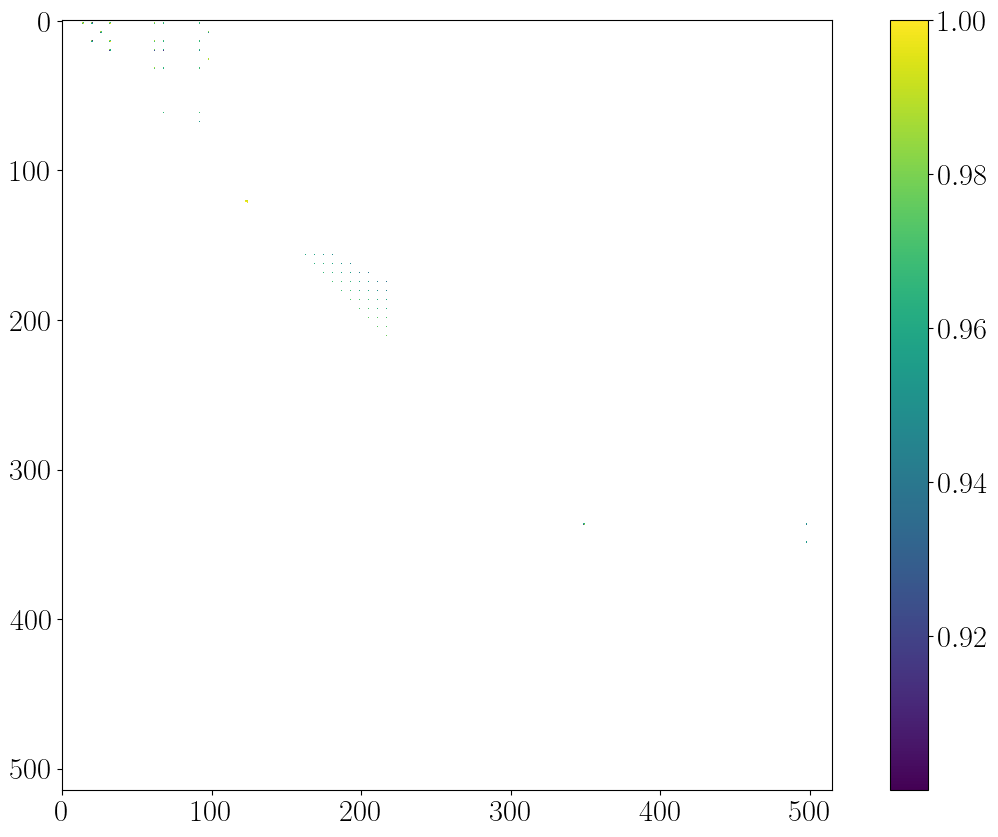

In [36]:
plt.imshow(tri_upper_corr[tri_upper_corr>0.9])
plt.colorbar()

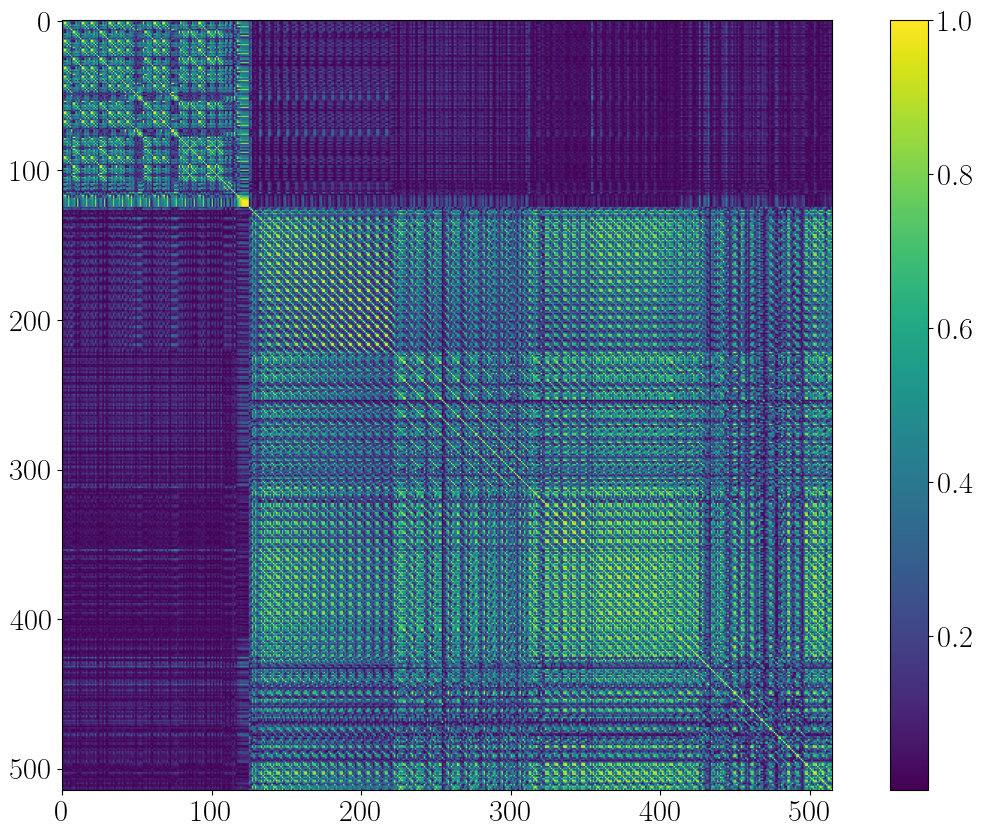

In [37]:
plt.imshow(CORR)
plt.colorbar()